<a href="https://colab.research.google.com/github/ssprajapati2021/Hybrid-RAG-Fine-Tuning/blob/main/notebook/Fine_Tuning_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 6: Fine-Tuning Pipeline**
## Assignment: Hybrid RAG & Fine-Tuning for Customer Support
---

### TO-DO: Before Running This Notebook

**Files you NEED:**
- [ ] `./tokenized_train/` + `./tokenized_valid/` — Created by Notebook 2
- [ ] GPU runtime enabled (T4 minimum)

**Files this notebook will CREATE:**
- [ ] `./intent_lora_best/` — Best LoRA checkpoint (by val loss) _(Required by NB7)_
- [ ] `./intent_lora/` — Final LoRA checkpoint _(Backup)_
- [ ] `training_log.csv` + `training_curves.png` — Evidence for report

---

*****Setup to Get Files needed from Notebook2*****

In [1]:
# Mount Google Drive to access the artifacts
from google.colab import drive

drive.mount('/content/drive')

# Define Paths
artifact_path = "/content/drive/MyDrive/corporate_policies"

# Model Uses in previous notebooks

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Install Dependencies
!pip install -U bitsandbytes>=0.46.1

## **Stage 4: Solution V2 (Fine-Tuned Retrieval-Assisted Generation)**

### **Task 4.1: Configure Fine-Tuning Pipeline**

#### **4.1.1 Configure PEFT Framework [3 marks]**
**The Task:** Apply LoRA (or QLoRA) to the model's `q_proj` and `v_proj` attention modules, set adapter settings and target modules, and prepare the training environment.

**Hints & Tips:**
* LoRA adds small trainable matrices to frozen attention layers — only ~0.5–1% of params update.
* `r=16` = rank of the low-rank matrices; `lora_alpha=32` scales them (rule of thumb: alpha = 2×r).
* `target_modules=["q_proj","v_proj"]`. Adding `["k_proj","o_proj"]` trains more params but may overfit on small data.
* Call `peft_model.print_trainable_parameters()` to confirm the tiny trainable %.

**LoRA Config Tuning:**
* `r`: 8 (lighter), **16 (recommended)**, 32 (more capacity).
* `lora_alpha`: usually 2×r → 16, **32**, 64.

**Learner Inference:** Updating only attention projections fundamentally changes behaviour (chat → JSON) using a fraction of the compute.

In [3]:
# Load the model
from transformers import AutoModelForCausalLM
from transformers import BitsAndBytesConfig
import torch

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True

)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [4]:
from peft import (
    LoraConfig,
    get_peft_model,
    TaskType
)

# Configure LoRA
lora_config = LoraConfig(

    task_type=TaskType.CAUSAL_LM,

    r=16,

    lora_alpha=32,

    lora_dropout=0.05,

    bias="none",

    target_modules=[
        "q_proj",
        "v_proj"
    ]
)

# Apply LoRA
peft_model = get_peft_model(
    model,
    lora_config
)

# Verify Trainable Parameters
peft_model.print_trainable_parameters()

trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


In [5]:
model = peft_model

#### **4.1.2 Configure Training Parameters [2 marks]**
**The Task:** Define the learning rate, batch size, number of steps/epochs, optimisation strategy (AdamW), and quantisation settings.

**Hints & Tips:**
* Initialise `AdamW(filter(lambda p: p.requires_grad, peft_model.parameters()), lr=2e-4)`.
* Build `DataLoader`s for the train and validation sets (remember `set_format("torch", ...)` after `load_from_disk`).
* Define `VAL_EVERY` (e.g. 10 steps) and an early-stopping `PATIENCE` (e.g. 3) for the next task.

**Parameter Tuning:**
* `lr=2e-4` standard; try `1e-4` (slower) or `5e-4` (faster).
* `batch_size=4` fits T4; use 2 if OOM, 8 on A100.
* `max_steps=200`: ~25% of one epoch on 3200 rows. Increase to 400–500 for a full epoch.

**Learner Inference:** These hyperparameters control how fast and how stably the adapter learns the JSON-extraction task.

In [6]:
# Load Tokenized Datasets
from datasets import load_from_disk

train_dataset = load_from_disk(f"{artifact_path}/tokenized_train")
valid_dataset = load_from_disk(f"{artifact_path}/tokenized_valid")

In [7]:
from torch.utils.data import DataLoader

# Set PyTorch Format
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

valid_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)


# Create DataLoaders
BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Configure Optimizer
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, peft_model.parameters()),
    lr=2e-4
)

# Training Hyperparameters
LEARNING_RATE = 2e-4
NUM_EPOCHS = 1

MAX_STEPS = 200

VAL_EVERY = 10

PATIENCE = 3

print("Training Configuration")
print("----------------------")
print(f"Learning Rate : {LEARNING_RATE}")
print(f"Batch Size    : {BATCH_SIZE}")
print(f"Max Steps     : {MAX_STEPS}")
print(f"Validation    : Every {VAL_EVERY} steps")
print(f"Patience      : {PATIENCE}")

Training Configuration
----------------------
Learning Rate : 0.0002
Batch Size    : 4
Max Steps     : 200
Validation    : Every 10 steps
Patience      : 3


### **Task 4.2: Train Fine-Tuned Model**

#### **4.2.1 Execute Fine-Tuning [5 marks]**
**The Task:** Run the custom PyTorch training loop. Monitor BOTH train and validation loss at regular intervals, implement early stopping based on validation loss, and plot the train-vs-validation loss curves.

**Hints & Tips:**
* The validation loop runs every `VAL_EVERY` steps under `torch.no_grad()` (no gradients).
* Early stopping: track `best_val_loss`; if it doesn't improve for `PATIENCE` checks, stop.
* The loss-curve plot is mandatory evidence — save it as `training_curves.png`.

**What to look for in the curve:**
* Both lines falling → learning, no overfitting.
* Val rises while train falls → overfitting (early stopping saves you).
* Both flat → LR too low or data too small.
* Val spikes → bad batch / instability.

**Learner Inference:** Falling loss proves gradient descent is teaching the JSON format. Validation monitoring prevents silent memorisation.

****Note:**** Upgraded `datasets` to fix a compatibility issue with the runtime (`torchvision`/`VideoReader`), enabling successful dataset loading and training.

In [13]:
!pip install -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 16.6 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [15]:
print(datasets.__version__)

5.0.1


In [9]:
import os
import torch
from copy import deepcopy
#from torchvision.io import VideoReader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
peft_model.to(device)

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None

patience_counter = 0
global_step = 0
stop_training = False

print("Starting Fine-Tuning...\n")

for epoch in range(NUM_EPOCHS):

    peft_model.train()

    for batch in train_loader:

        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = peft_model(**batch)

        loss = outputs.loss

        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        train_losses.append(loss.item())

        global_step += 1

        # ----------------------------
        # Validation
        # ----------------------------
        if global_step % VAL_EVERY == 0:

            peft_model.eval()

            total_val_loss = 0

            with torch.no_grad():

                for val_batch in valid_loader:

                    val_batch = {
                        k: v.to(device)
                        for k, v in val_batch.items()
                    }

                    val_outputs = peft_model(**val_batch)

                    total_val_loss += val_outputs.loss.item()

            avg_val_loss = total_val_loss / len(valid_loader)

            val_losses.append(avg_val_loss)

            print(
                f"Step {global_step:4d} | "
                f"Train Loss: {loss.item():.4f} | "
                f"Val Loss: {avg_val_loss:.4f}"
            )

            # ----------------------------
            # Early Stopping
            # ----------------------------
            if avg_val_loss < best_val_loss:

                best_val_loss = avg_val_loss

                patience_counter = 0

                best_model_state = deepcopy(
                    peft_model.state_dict()
                )

            else:

                patience_counter += 1

                print(
                    f"No improvement "
                    f"({patience_counter}/{PATIENCE})"
                )

                if patience_counter >= PATIENCE:

                    print("\nEarly stopping triggered.")

                    stop_training = True

                    break

            peft_model.train()

        # ----------------------------
        # Max Steps
        # ----------------------------
        if global_step >= MAX_STEPS:

            stop_training = True

            break

    if stop_training:

        break

  # Restore Best Model
    if best_model_state is not None:

      peft_model.load_state_dict(best_model_state)

      print("Best model restored.")




Starting Fine-Tuning...

Step   10 | Train Loss: 2.9605 | Val Loss: 2.9531
Step   20 | Train Loss: 1.7334 | Val Loss: 1.6112
Step   30 | Train Loss: 1.3332 | Val Loss: 1.2057
Step   40 | Train Loss: 1.2232 | Val Loss: 1.1416
Step   50 | Train Loss: 1.1076 | Val Loss: 1.0865
Step   60 | Train Loss: 1.0846 | Val Loss: 1.0288
Step   70 | Train Loss: 0.9332 | Val Loss: 0.9642
Step   80 | Train Loss: 0.8301 | Val Loss: 0.8876
Step   90 | Train Loss: 0.7268 | Val Loss: 0.8046
Step  100 | Train Loss: 0.7666 | Val Loss: 0.7440
Step  110 | Train Loss: 0.6640 | Val Loss: 0.6982
Step  120 | Train Loss: 0.6315 | Val Loss: 0.6694
Step  130 | Train Loss: 0.5916 | Val Loss: 0.6461
Step  140 | Train Loss: 0.6007 | Val Loss: 0.6357
Step  150 | Train Loss: 0.6453 | Val Loss: 0.6184
Step  160 | Train Loss: 0.6081 | Val Loss: 0.6055
Step  170 | Train Loss: 0.7107 | Val Loss: 0.5913
Step  180 | Train Loss: 0.5617 | Val Loss: 0.5861
Step  190 | Train Loss: 0.5403 | Val Loss: 0.5732
Step  200 | Train Loss: 0

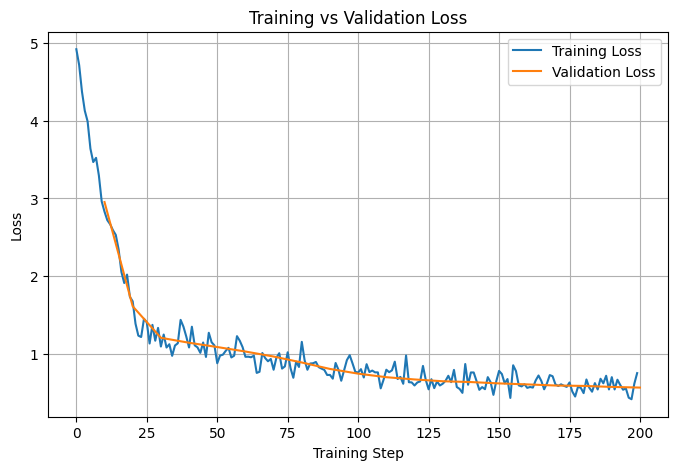

Saved: /content/drive/MyDrive/corporate_policies/training_curves.png


In [10]:
# Plot Loss Curves
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label="Training Loss"
)

val_x = [
    VAL_EVERY * (i + 1)
    for i in range(len(val_losses))
]

plt.plot(
    val_x,
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Training Step")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plot_path = os.path.join(
    artifact_path,
    "training_curves.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", plot_path)


In [11]:
# Final Summary
print("="*50)
print("Training Completed")
print("="*50)

print(f"Best Validation Loss : {best_val_loss:.4f}")
print(f"Training Steps       : {global_step}")
print(f"Training Records     : {len(train_losses)}")
print(f"Validation Records   : {len(val_losses)}")

Training Completed
Best Validation Loss : 0.5645
Training Steps       : 200
Training Records     : 200
Validation Records   : 20


#### **4.2.2 Save Training Outputs [2 marks]**
**The Task:** Save the best checkpoint (by validation loss), document the checkpoint/model-saving workflow, and export reproducibility information.

**Hints & Tips:**
* Save two checkpoints: `./intent_lora_best/` (lowest val loss) and `./intent_lora/` (final step).
* Export a `training_log.csv` with columns `step, train_loss, val_loss`.
* Record reproducibility info: model ID, LoRA config, learning rate, batch size, seed.

**Learner Inference:** Saving the BEST checkpoint (not the last) ensures your final model is the one that generalised best, not one that started overfitting.

In [13]:
import pandas as pd

# Best Checkpoint
best_model_path = os.path.join(
    artifact_path,
    "intent_lora_best"
)

peft_model.save_pretrained(best_model_path)

print("✅ Best checkpoint saved.")

# Final Checkpoint
final_model_path = os.path.join(
    artifact_path,
    "intent_lora"
)

peft_model.save_pretrained(final_model_path)

print("✅ Final checkpoint saved.")

# Creating training_log.csv

steps = list(range(
    VAL_EVERY,
    (len(val_losses) * VAL_EVERY) + 1,
    VAL_EVERY
))

training_log = pd.DataFrame({
    "step": steps,
    "train_loss": train_losses[VAL_EVERY-1::VAL_EVERY],
    "val_loss": val_losses
})

training_log.to_csv(
    os.path.join(
        artifact_path,
        "training_log.csv"
    ),
    index=False
)

training_log.head()


✅ Best checkpoint saved.
✅ Final checkpoint saved.


,step,train_loss,val_loss
0,10,2.960495,2.953080
1,20,1.733423,1.611153
2,30,1.333221,1.205688
3,40,1.223164,1.141624
4,50,1.107556,1.086505


In [14]:
# Creating reproducibility.csv

reproducibility = pd.DataFrame({

    "Parameter":[
        "Model ID",
        "LoRA Rank",
        "LoRA Alpha",
        "Target Modules",
        "Learning Rate",
        "Batch Size",
        "Max Steps",
        "Validation Every",
        "Patience",
        "Quantization",
        "Optimizer",
        "Seed"
    ],

    "Value":[
        MODEL_ID,
        16,
        32,
        "q_proj,v_proj",
        LEARNING_RATE,
        BATCH_SIZE,
        MAX_STEPS,
        VAL_EVERY,
        PATIENCE,
        "4-bit NF4",
        "AdamW",
        42
    ]

})

reproducibility.to_csv(
    os.path.join(
        artifact_path,
        "reproducibility.csv"
    ),
    index=False
)

reproducibility

,Parameter,Value
0,Model ID,Qwen/Qwen2.5-1.5B-Instruct
1,LoRA Rank,16
2,LoRA Alpha,32
3,Target Modules,"q_proj,v_proj"
4,Learning Rate,0.0002
5,Batch Size,4
6,Max Steps,200
7,Validation Every,10
8,Patience,3
9,Quantization,4-bit NF4


**Observation:** Validation loss continued to decrease throughout training and reached its minimum at the final training step (200). Therefore, the final checkpoint is also the best-performing checkpoint, resulting in identical adapter weights being saved in both intent_lora_best and intent_lora.

---
## END-OF-NOTEBOOK CHECKLIST

> **IMPORTANT: Verify before proceeding to Notebook 7.**

- [x] Tokenized train/valid loaded from disk (`set_format` re-applied)
- [x] **4.1.1** LoRA configured targeting `q_proj`/`v_proj`
- [x] **4.1.2** Optimizer + training params + dataloaders set
- [x] **4.2.1** Training loop run with val monitoring + early stopping + loss curve
- [x] **4.2.2** Best checkpoint saved + reproducibility info recorded
- [x] **`./intent_lora_best/` saved** ← _CRITICAL for NB7_
- [x] **`training_log.csv` + `training_curves.png` saved** ← _Evidence_

**If any item is unchecked, fix it before moving on.**